<a href="https://colab.research.google.com/github/GunaSamhith/ML-labActivity/blob/main/11_4_1_PrincipleComponentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

In [ ]:
rng = np.random.default_rng(42)
n = 600

area_sqft       = rng.normal(1800, 500, n).clip(600, 4000)
bedrooms        = np.clip(np.round(area_sqft/600 + rng.normal(0, .6, n)), 1, 6)
bathrooms       = np.clip(np.round(bedrooms*0.7 + rng.normal(0, .5, n)), 1, 5)
age_years       = rng.gamma(3, 8, n).clip(0, 80)
dist_city_km    = rng.gamma(2.5, 6, n).clip(1, 60)
dist_school_km  = (0.15*dist_city_km + rng.gamma(2, 1.2, n)).clip(0.2, 25)
crime_index     = (20 + 1.2*dist_city_km*0.3 + rng.normal(0, 12, n)).clip(1, 100)
walk_score      = (85 - 1.5*dist_city_km + rng.normal(0, 10, n)).clip(5, 100)
condition_score = (9 - 0.06*age_years + rng.normal(0, 1, n)).clip(1, 10)

fair_price = (area_sqft*95 + bedrooms*4000 + bathrooms*3000
              - age_years*700 - dist_city_km*900 - crime_index*250
              + walk_score*300 + condition_score*4000 + 60000)
overpricing_pct = rng.normal(5, 12, n)
asking_price    = fair_price*(1 + overpricing_pct/100)
price_per_sqft  = asking_price/area_sqft
hoa_fee         = rng.gamma(2, 90, n).clip(0, 900)
photos_count    = rng.integers(3, 30, n)
listing_quality = (photos_count/30*10 + rng.normal(0, 1.5, n)).clip(1, 10)

z = (0.09*overpricing_pct + 0.05*dist_city_km + 0.03*crime_index
     + 0.04*age_years - 0.02*walk_score - 0.5*condition_score
     - 0.25*listing_quality + 0.002*hoa_fee + 1.0)
p_unsold = 1/(1 + np.exp(-z))
days_on_market = (40 + 260*p_unsold + rng.normal(0, 25, n)).clip(5, 400)
unsold_6m = (days_on_market > 180).astype(int)

df = pd.DataFrame({
    'asking_price': asking_price.round(0), 'area_sqft': area_sqft.round(0),
    'bedrooms': bedrooms, 'bathrooms': bathrooms, 'age_years': age_years.round(1),
    'dist_city_km': dist_city_km.round(1), 'dist_school_km': dist_school_km.round(1),
    'crime_index': crime_index.round(1), 'walk_score': walk_score.round(0),
    'condition_score': condition_score.round(1), 'overpricing_pct': overpricing_pct.round(1),
    'price_per_sqft': price_per_sqft.round(1), 'hoa_fee': hoa_fee.round(0),
    'photos_count': photos_count, 'listing_quality': listing_quality.round(1),
    'days_on_market': days_on_market.round(0), 'unsold_6m': unsold_6m
})
df.to_csv('maggie_properties.csv', index=False)
print(df.shape)
print(df['unsold_6m'].value_counts())
df.head()

(600, 17)
unsold_6m
0    526
1     74
Name: count, dtype: int64


,asking_price,area_sqft,bedrooms,bathrooms,age_years,dist_city_km,dist_school_km,crime_index,walk_score,condition_score,overpricing_pct,price_per_sqft,hoa_fee,photos_count,listing_quality,days_on_market,unsold_6m
0,262186.0,1952.0,4.0,2.0,20.8,24.8,5.2,34.2,50.0,7.5,-1.8,134.3,92.0,27,8.8,21.0,0
1,209088.0,1280.0,2.0,1.0,17.6,20.7,5.6,41.6,70.0,7.8,2.7,163.3,235.0,29,8.3,63.0,0
2,291777.0,2175.0,4.0,3.0,22.6,10.1,3.3,2.5,72.0,6.6,-7.1,134.1,388.0,29,10.0,69.0,0
3,345857.0,2270.0,3.0,2.0,28.2,14.1,4.2,39.3,50.0,8.6,15.0,152.3,225.0,29,9.6,84.0,0
4,200412.0,824.0,1.0,1.0,21.9,8.6,5.8,19.4,74.0,8.6,15.2,243.1,134.0,3,1.0,85.0,0


In [ ]:
df.groupby('unsold_6m').mean().T.round(2)

unsold_6m,0,1
asking_price,271301.38,255854.46
area_sqft,1799.36,1703.45
bedrooms,2.99,2.84
bathrooms,2.07,1.97
age_years,22.53,38.20
dist_city_km,14.06,22.07
dist_school_km,4.46,5.47
crime_index,25.57,31.45
walk_score,64.33,52.00
condition_score,7.72,6.26


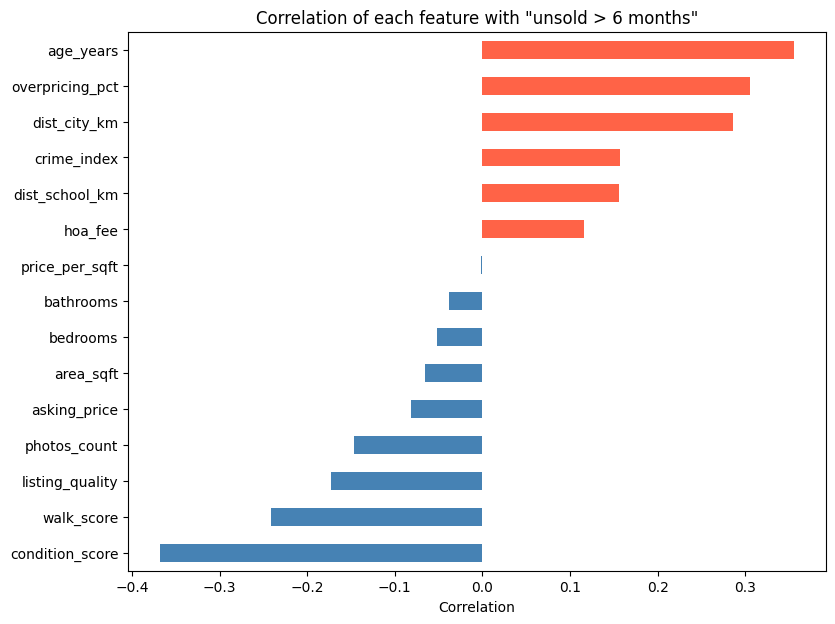

In [ ]:
features = df.drop(columns=['days_on_market', 'unsold_6m']).columns

plt.figure(figsize=(9, 7))
corr = df[list(features) + ['unsold_6m']].corr()['unsold_6m'].drop('unsold_6m').sort_values()
corr.plot(kind='barh', color=['tomato' if v > 0 else 'steelblue' for v in corr])
plt.title('Correlation of each feature with "unsold > 6 months"')
plt.xlabel('Correlation')
plt.show()

In [ ]:
X = df[features]
scaled = StandardScaler().fit_transform(X)
print(scaled.shape)

(600, 15)


In [ ]:
pca = PCA()
pcs = pca.fit_transform(scaled)

var_ratio = pca.explained_variance_ratio_
print(np.round(var_ratio, 3))
print('Cumulative:', np.round(np.cumsum(var_ratio), 3))

[0.214 0.184 0.133 0.123 0.088 0.067 0.059 0.04  0.032 0.022 0.014 0.012
 0.008 0.003 0.   ]
Cumulative: [0.214 0.397 0.531 0.654 0.742 0.809 0.867 0.907 0.94  0.962 0.976 0.988
 0.997 1.    1.   ]


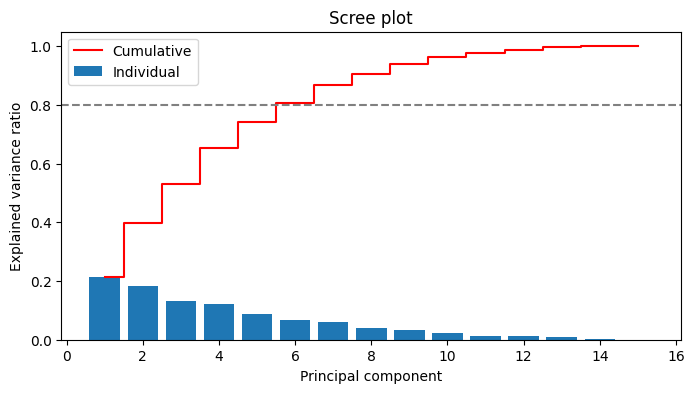

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(var_ratio)+1), var_ratio, label='Individual')
plt.step(range(1, len(var_ratio)+1), np.cumsum(var_ratio), where='mid', color='red', label='Cumulative')
plt.axhline(0.8, ls='--', color='gray')
plt.xlabel('Principal component')
plt.ylabel('Explained variance ratio')
plt.title('Scree plot')
plt.legend()
plt.show()

In [ ]:
pca3 = PCA(n_components=3)
comp = pca3.fit_transform(scaled)

loadings = pd.DataFrame(pca3.components_.T, index=features, columns=['PC1', 'PC2', 'PC3'])
loadings.round(3)

,PC1,PC2,PC3
asking_price,0.449,-0.200,0.222
area_sqft,0.519,0.060,-0.012
bedrooms,0.503,0.037,0.010
bathrooms,0.440,0.011,0.019
age_years,-0.023,0.040,-0.538
dist_city_km,-0.059,0.511,0.204
dist_school_km,-0.034,0.424,0.198
crime_index,0.001,0.220,0.125
walk_score,0.056,-0.482,-0.199
condition_score,0.019,-0.030,0.540


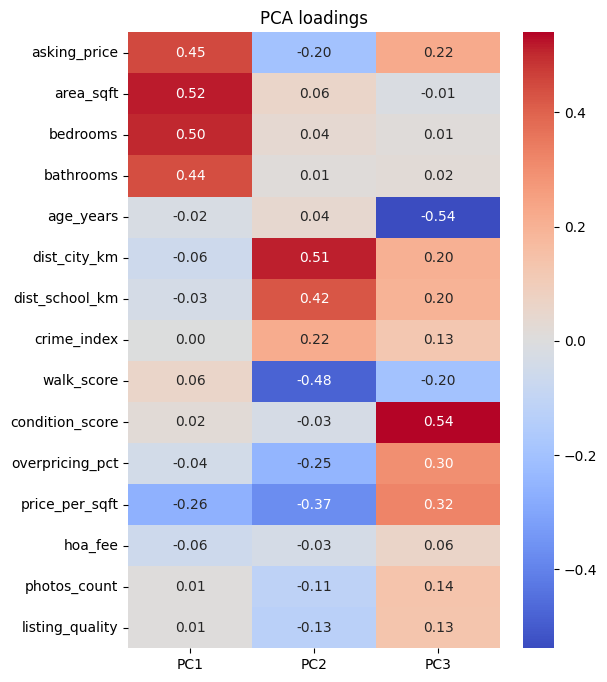

PC1 -> top drivers: ['area_sqft', 'bedrooms', 'asking_price', 'bathrooms', 'price_per_sqft']
PC2 -> top drivers: ['dist_city_km', 'walk_score', 'dist_school_km', 'price_per_sqft', 'overpricing_pct']
PC3 -> top drivers: ['condition_score', 'age_years', 'price_per_sqft', 'overpricing_pct', 'asking_price']


In [ ]:
plt.figure(figsize=(6, 8))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('PCA loadings')
plt.show()

for pc in ['PC1', 'PC2', 'PC3']:
    top = loadings[pc].abs().sort_values(ascending=False).head(5).index
    print(pc, '-> top drivers:', list(top))

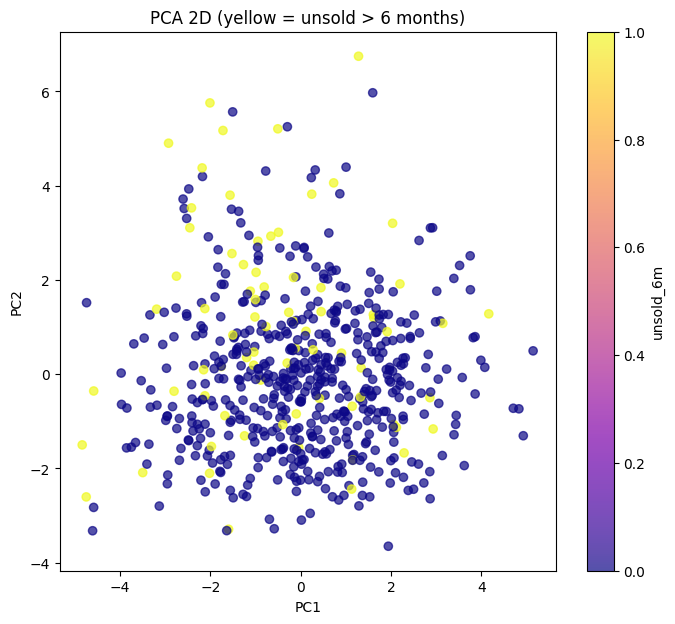

In [ ]:
plt.figure(figsize=(8, 7))
plt.scatter(comp[:, 0], comp[:, 1], c=df['unsold_6m'], cmap='plasma', alpha=.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D (yellow = unsold > 6 months)')
plt.colorbar(label='unsold_6m')
plt.show()

In [ ]:
std_df = pd.DataFrame(scaled, columns=features)
std_df['unsold_6m'] = df['unsold_6m'].values
m = std_df.groupby('unsold_6m').mean()

print("Standardized difference (unsold minus sold):")
print((m.loc[1] - m.loc[0]).sort_values(ascending=False).round(2))

print()
for i, name in enumerate(['PC1', 'PC2', 'PC3']):
    print(f"Mean {name} score (sold, unsold):",
          comp[df.unsold_6m == 0, i].mean().round(2),
          comp[df.unsold_6m == 1, i].mean().round(2))

Standardized difference (unsold minus sold):
age_years          1.08
overpricing_pct    0.93
dist_city_km       0.87
crime_index        0.48
dist_school_km     0.47
hoa_fee            0.35
price_per_sqft    -0.00
bathrooms         -0.12
bedrooms          -0.16
area_sqft         -0.20
asking_price      -0.25
photos_count      -0.45
listing_quality   -0.52
walk_score        -0.73
condition_score   -1.12
dtype: float64

Mean PC1 score (sold, unsold): 0.07 -0.5
Mean PC2 score (sold, unsold): -0.13 0.95
Mean PC3 score (sold, unsold): 0.07 -0.53
